## Setup

In [1]:
import os, subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import lightning
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

from mlcolvar.cvs import DeepLDA
from mlcolvar.data import DictDataset, DictModule
from mlcolvar.utils.io import load_dataframe, create_dataset_from_files
from mlcolvar.utils.trainer import MetricsCallback
from mlcolvar.utils.plot import plot_metrics
from mlcolvar.utils.fes import compute_fes
from mlcolvar.explain.sensitivity import sensitivity_analysis

In [2]:
# Configurations
BASE_DIR   = Path("/home/dani/wslcoding/MCFM/ML-CV")
INPUT_DIR  = BASE_DIR / "input"
SAMPLE_DIR = BASE_DIR / "sample"
GMX_CMD    = "gmx_mpi"
NUM_STEPS  = 10_000   # productions: 500_000
STRIDE     = 100

# ── Reproducibility ───────────────────────────────────────────────────────
torch.manual_seed(42)

os.chdir(BASE_DIR)

In [3]:
# Check working directory
os.getcwd()

'/home/dani/wslcoding/MCFM/ML-CV'

In [4]:
# Helper functions

def clean(folder='./'):
    """Remove GROMACS / PLUMED output files from a simulation folder."""
    subprocess.run("rm -f bck.* COLVAR KERNELS alanine.*", cwd=folder, shell=True)


def execute(command, folder, background=False):
    """Execute a shell command inside *folder* and print its exit status."""
    cmd = subprocess.run(
        command, cwd=folder, shell=True,
        capture_output=True, text=True, close_fds=background
    )
    if cmd.returncode == 0:
        print(f'Completed: {command}')
    else:
        print(cmd.stderr)

In [5]:
# ── Plotting helper functions ─────────────────────────────────────────────
# These are retained from the original notebook with minor style cleanup.

def plot_ramachandran(x, y, z, ax=None):
    """Hexbin Ramachandran plot coloured by the DeepLDA CV value."""
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4), dpi=100)
        ax.set_title('Ramachandran plot')
    h = ax.hexbin(x, y, C=z, cmap='coolwarm')
    cbar = plt.colorbar(h, ax=ax)
    cbar.set_label('Deep-LDA CV')
    ax.set_xlabel(r'$\phi$ [rad]')
    ax.set_ylabel(r'$\psi$ [rad]')


def plot_cv_histogram(s, label=None, ax=None, **kwargs):
    """Histogram of the CV values; accepts both tensors and numpy arrays."""
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4), dpi=100)
        ax.set_title('Histogram')
    # Convert torch.Tensor to numpy if necessary
    if isinstance(s, torch.Tensor):
        s = s.squeeze(1).detach().numpy()
    ax.hist(s, **kwargs)
    if label is not None:
        ax.set_xlabel(label)

## 1.1 DeepLDA CV on pairwise distances (heavy atoms) 

### (a) Train CV

To load the PLUMED output of the two unbiased MD runs we can use the [load_dataframe](https://mlcvs.readthedocs.io/en/latest/autosummary/mlcvs.utils.io.load_dataframe.html) function.
From this data, we build our training dataset. Since this is a supervised learning task, the dataset will be of the form (`X,y`), in which `X` are the input samples and `y` the corresponding labels (the states to which they belong to).

In [ ]:
# ── MIGRATION NOTE ────────────────────────────────────────────────────────
# Old (mlcvs):
#   from mlcvs.utils.io import load_dataframe
#   colvarA = load_dataframe(...)
#   X = torch.Tensor(colvar.filter(regex='d_').values)
#   y = torch.Tensor(colvar['label'].values)
#   dataset = TensorDataset(X, y)
#   train_loader = FastTensorDataLoader(...)
#
# New (mlcolvar):
#   create_dataset_from_files handles all of the above and returns a
#   DictDataset with keys 'data' (features) and 'labels' (class indices).
# ─────────────────────────────────────────────────────────────────────────

n_states = 2  # A (C7eq) and B (C7ax)

filenames = [
    'sample/0_unbiased-sA/COLVAR',
    'sample/0_unbiased-sB/COLVAR',
]

# filter_args selects only columns matching the regex 'd_' (pairwise distances)
dataset, df = create_dataset_from_files(
    filenames,
    return_dataframe=True,
    filter_args={'regex': 'd_'},   # keep only distance descriptors
)

# Inspect the loaded tensors
X      = dataset[:]['data']    # shape: (N, n_features)
labels = dataset[:]['labels']  # shape: (N,)  integer class indices

print(f"Descriptor matrix X      : {X.shape}")
print(f"Class label vector labels: {labels.shape}")
print(f"Dataframe columns        : {list(df.columns[:6])} ...")


Class 0 dataframe shape:  (101, 53)
Class 1 dataframe shape:  (101, 53)

 - Loaded dataframe (202, 53): ['time', 'phi', 'psi', 'theta', 'xi', 'ene', 'd_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15', 'd_11_16', 'd_11_17', 'd_11_19', 'd_15_16', 'd_15_17', 'd_15_19', 'd_16_17', 'd_16_19', 'd_17_19', 'walker', 'labels']
 - Descriptors (202, 45): ['d_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15', 'd_

We can take a look at the descriptors, by computing their histogram in the two states. 

--> **Question:** Is there any descriptor that is able to discriminate by its own between the states?

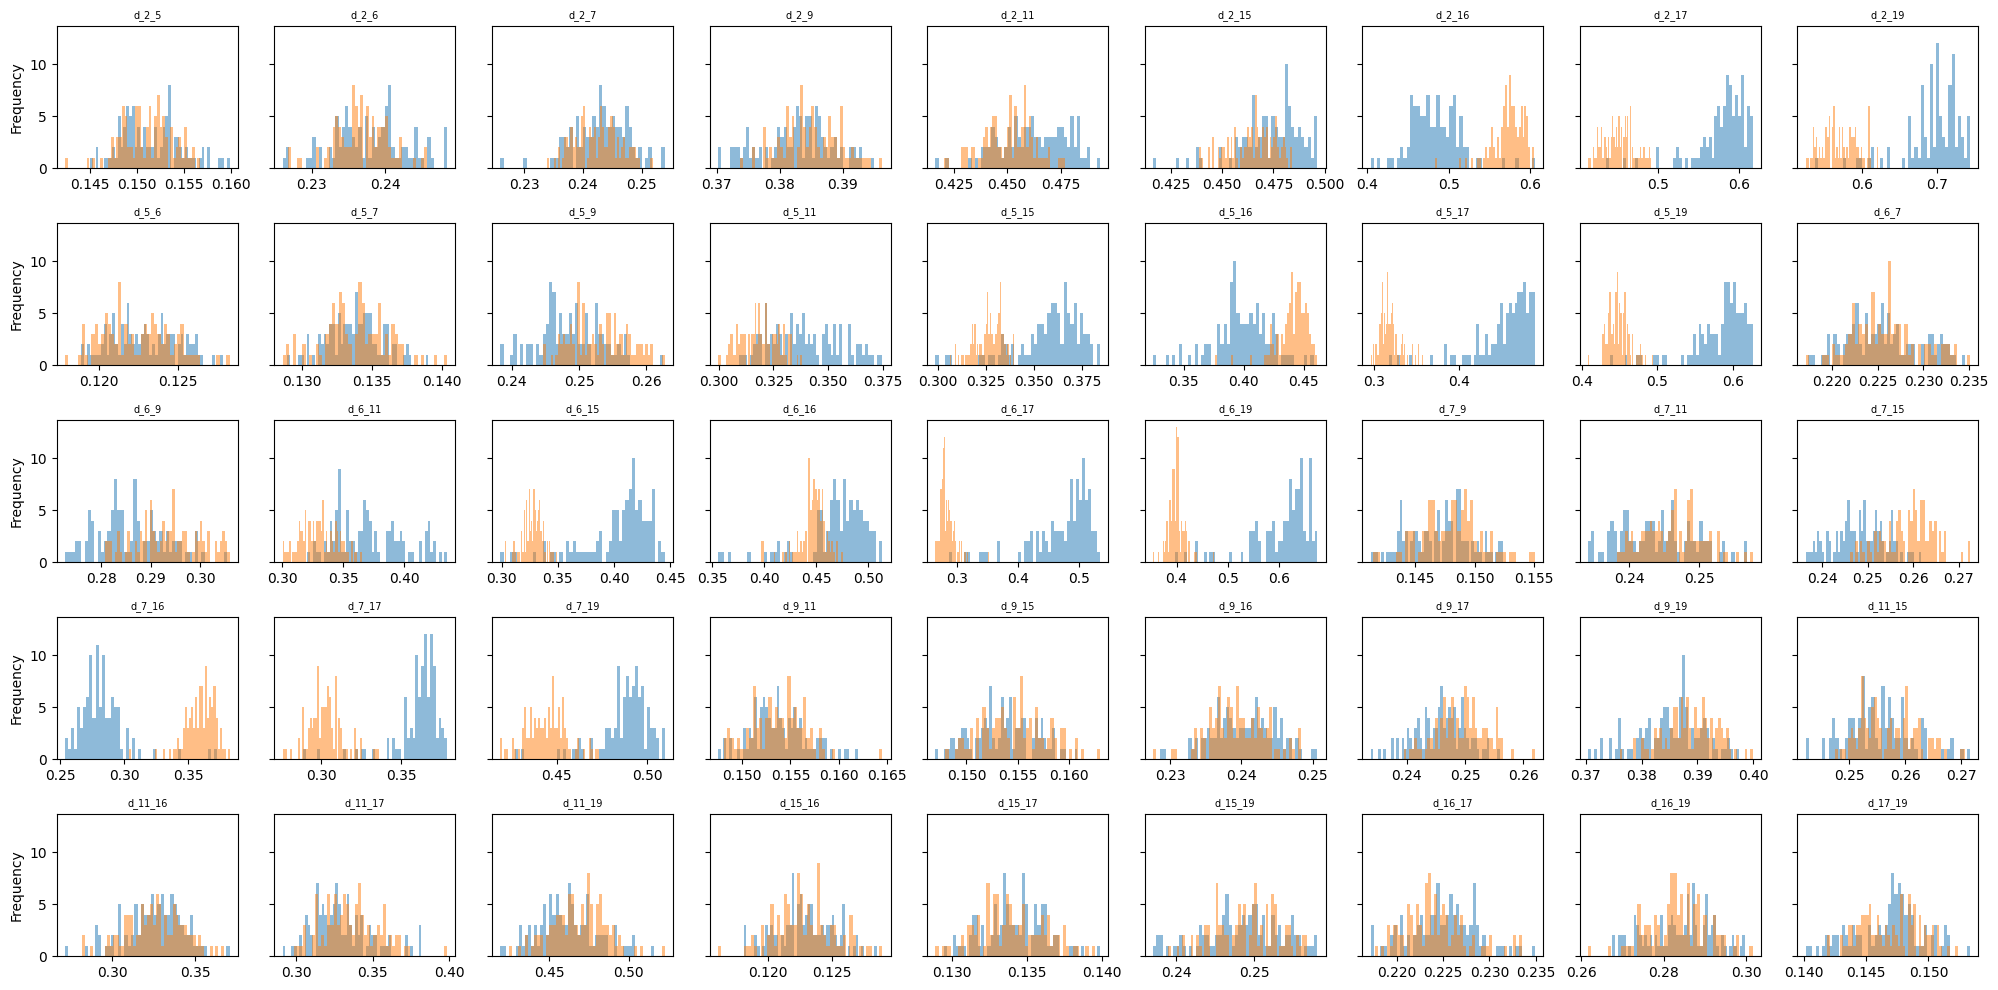

In [7]:
# ── Histogram of each descriptor in states A and B ────────────────────────
# The 'state' column (added by create_dataset_from_files as 'labels') is used
# to split the data; 'labels' == 0 → state A, 'labels' == 1 → state B.

descriptor_cols = [c for c in df.columns if c.startswith('d_')]
n_desc = len(descriptor_cols)

fig, axs = plt.subplots(5, 9, figsize=(20, 10), sharey=True)

for ax, col in zip(axs.flatten(), descriptor_cols):
    df.groupby('labels')[col].plot.hist(bins=50, alpha=0.5, ax=ax, legend=False)
    ax.set_title(col, fontsize=7)

plt.tight_layout()
plt.show()

Here we use the [mlcvs](https://mlcvs.readthedocs.io) package to train a DeepLDA CV out of this data. This can be as simple as follows: define the network architecture, specify when to stop to training (e.g. by using early stopping on validation score) and call the fit method. This will output the training and validation score along the training. Let's give it a try!

In [8]:
# ── Hyperparameters ───────────────────────────────────────────────────────
n_features   = X.shape[1]   # number of input descriptors
nn_layers    = [n_features, 30, 30, 5]  # [input, hidden..., NN output]
activation   = 'tanh'
sw_reg       = 0.05   # β: S_w regularisation (λ in old notation)
# Note: α = 2/β is set automatically inside FisherDiscriminantLoss

nn_options = {'activation': activation}
options    = {'nn': nn_options}          # no 'lda' key needed

model = DeepLDA(nn_layers, n_states=n_states, options=options)

# sw_reg (β) controls S_w' = S_w + β·I;  lorentzian_reg = α = 2/β
# These two are coupled as in Bonati, Rizzi & Parrinello (2020).
model.lorentzian_reg = 2.0 / sw_reg     # = 40 for sw_reg = 0.05

print(model)
print(f"lorentzian_reg (α = 2/β): {model.lorentzian_reg}")

DeepLDA(
  (loss_fn): ReduceEigenvaluesLoss()
  (norm_in): Normalization(in_features=45, out_features=45, mode=mean_std)
  (nn): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=45, out_features=30, bias=True)
      (1): Tanh()
      (2): Linear(in_features=30, out_features=30, bias=True)
      (3): Tanh()
      (4): Linear(in_features=30, out_features=5, bias=True)
    )
  )
  (lda): LDA(in_features=5, out_features=1)
)
lorentzian_reg (α = 2/β): 40.0


However, to better understand what we are doing, we shall consider a more detailed example, in which we analyze the different steps and options. First we create a `TensorDataset` which we then divide into training and validation set. From them, we construct `Dataloader`-like objects. The definition of such auxiliary objects is a standard PyTorch practice, which allows us to easily train the models on different devices.

In [9]:
datamodule = DictModule(dataset, lengths=[0.8, 0.2])
print(datamodule)

{Train dataloader: None}
{Validation dataloader: None}
{Test dataloader: None}
{Predict dataloader: None}


Then, we need to inizialize the neural network and the optimizer and define when to stop the training (EarlyStopping or after a given number of epochs). The following is a list with all the parameters and their explanation. Note that we also standardize the inputs such that their range is betwen the -1 and 1 in the training set. 

| Parameter | Type | Description |
| :- | :- | :- |
| **Neural network** |
| nodes | list | NN architecture (last value equal to the number of hidden layers which are input of LDA) |
| activation | string | Activation function (relu,tanh,elu,linear) |
| **Optimization** |
| lrate | float | Learning rate |
| sw_reg | float | S_w matrix regularization ($\lambda$)| 
| l2_reg | float | L2 regularization |
| num_epochs | int | Number of epochs |
| **Early Stopping** |
| es_patience | int | Number of epochs before stopping |
| es_consecutive | bool | Whether es_patience should count consecutive (True) or cumulative patience |
| es_min_delta | float | Minimum decrease of validation loss |
| **Log** |
| log_every | int | How often print the train/valid loss during training |

In [10]:
# ── Training hyperparameters ──────────────────────────────────────────────
lrate       = 1e-3
l2_reg      = 1e-5
num_epochs  = 1000
es_patience = 20
es_min_delta = 0.1

# ── Optimiser ─────────────────────────────────────────────────────────────
# MIGRATION NOTE:
#   Old: model.set_optimizer(torch.optim.Adam(...))
#   New: configure_optimizers() is a Lightning hook; we override it before
#        calling trainer.fit().
optimizer = torch.optim.Adam(
    model.parameters(), lr=lrate, weight_decay=l2_reg
)
model.optimizer = optimizer

# ── Callbacks ─────────────────────────────────────────────────────────────
# MetricsCallback stores train/valid metrics at each epoch for later plotting.
# EarlyStopping replaces model.set_earlystopping(...).
metrics_cb = MetricsCallback()
early_stop = EarlyStopping(
    monitor="valid_eigval_1_epoch",
    mode='max',
    min_delta=es_min_delta,
    patience=es_patience,
)

# ── Trainer ───────────────────────────────────────────────────────────────
trainer = lightning.Trainer(
    callbacks=[metrics_cb, early_stop],
    max_epochs=num_epochs,
    logger=None,               # disable TensorBoard / CSV logging
    enable_checkpointing=False,
    enable_progress_bar=True,
)

# ── Fit ───────────────────────────────────────────────────────────────────
# MIGRATION NOTE:
#   Old: model.fit(train_loader, valid_loader,
#                  standardize_inputs=True, log_every=100)
#   New: trainer.fit(model, datamodule)
#   Input standardisation is handled automatically by model.norm_in.
trainer.fit(model, datamodule)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
2026-06-25 14:41:47.090528: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-25 14:41:47.7

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name    ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃ In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ loss_fn │ ReduceEigenvaluesLoss │      0 │ train │     0 │        ? │         ? │
│ 1 │ norm_in │ Normalization         │      0 │ train │     0 │  [1, 45] │   [1, 45] │
│ 2 │ nn      │ FeedForward           │  2.5 K │ train │ 4.8 K │  [1, 45] │    [1, 5] │
│ 3 │ lda     │ LDA                   │      0 │ train │    10 │   [1, 5] │    [1, 1] │
└───┴─────────┴───────────────────────┴────────┴───────┴───────┴──────────┴───────────┘

Trainable params: 2.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.5 K                                                                                                
Total estimated model params size (MB): 0.010                                                                      
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 4.8 K

/home/dani/ml/lib/python3.12/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/dani/ml/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches 
(1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if 
you want to see logs for the training epoch.

After the training we can plot the learning curve to see the training and validation score.

--> **Exercise**: You can try to repeat the training in the cell above and make sure that you find similar values for the loss function. You can examine the behaviour of the NN when changing the NN architecture, and in particular the number of outputs which regulates the space in which LDA is applied.

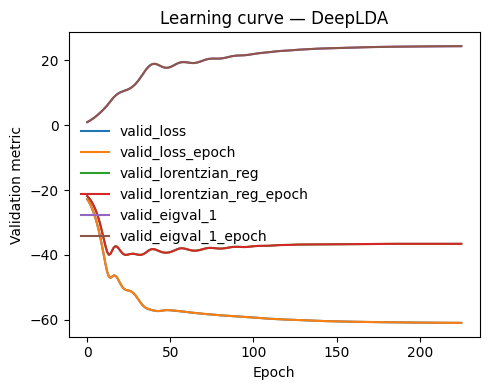

In [11]:
# ── MIGRATION NOTE ────────────────────────────────────────────────────────
# Old:
#   loss_train = [x.cpu().numpy() for x in model.loss_train]
#   ax.plot(loss_train, ...)
#
# New: plot_metrics reads from MetricsCallback.metrics dict
# ─────────────────────────────────────────────────────────────────────────

# Select keys corresponding to validation metrics (eigval and total loss)
valid_keys = [k for k in metrics_cb.metrics if 'valid' in k]

ax = plot_metrics(
    metrics_cb.metrics,
    keys=valid_keys,
    yscale='linear',
)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation metric')
ax.set_title('Learning curve — DeepLDA')
plt.tight_layout()
plt.show()


Finally, we can look at the histogram of the CV (right), which shows that the two states are mapped around -1 and +1. To appreciate the discriminative power, we can also inspect the Ramachandran plot (left) of the two torsion angles phi and psi where we colored the points according to the value of the Deep-LDA CV.

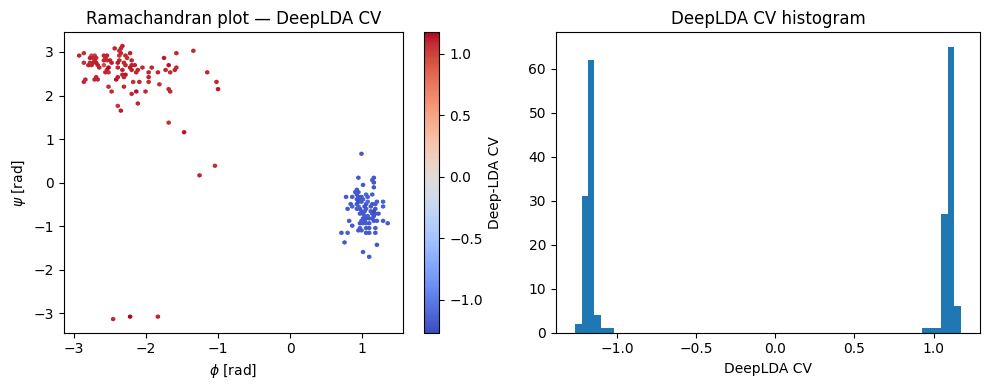

In [13]:
# ── Evaluate the model on the full dataset ────────────────────────────────
model.eval()
with torch.no_grad():
    s = model(X)  # shape: (N, 1)

# Retrieve torsion angles from the combined dataframe
# (they are stored in df even though we filtered them out of X)
phi_vals = df['phi'].values
psi_vals = df['psi'].values

fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=100)

axs[0].set_title('Ramachandran plot — DeepLDA CV')
plot_ramachandran(phi_vals, psi_vals, s.numpy().squeeze(), ax=axs[0])

axs[1].set_title('DeepLDA CV histogram')
plot_cv_histogram(s, label='DeepLDA CV', bins=60, ax=axs[1])

plt.tight_layout()
plt.show()


To better understand what the network is doing, we can inspect the output of the NN, before the application of LDA. 

--> **Question**: What are the differences with the input descriptors?

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training DeepLDA with NN output dim = 10 ...


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name    ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃ In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ loss_fn │ ReduceEigenvaluesLoss │      0 │ train │     0 │        ? │         ? │
│ 1 │ norm_in │ Normalization         │      0 │ train │     0 │  [1, 45] │   [1, 45] │
│ 2 │ nn      │ FeedForward           │  2.6 K │ train │ 5.1 K │  [1, 45] │   [1, 10] │
│ 3 │ lda     │ LDA                   │      0 │ train │    20 │  [1, 10] │    [1, 1] │
└───┴─────────┴───────────────────────┴────────┴───────┴───────┴──────────┴───────────┘

Trainable params: 2.6 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.6 K                                                                                                
Total estimated model params size (MB): 0.010                                                                      
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 5.1 K

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Trainable params: 2.4 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.4 K                                                                                                
Total estimated model params size (MB): 0.010                                                                      
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 4.7 K

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training DeepLDA with NN output dim = 1 ...


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name    ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃ In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ loss_fn │ ReduceEigenvaluesLoss │      0 │ train │     0 │        ? │         ? │
│ 1 │ norm_in │ Normalization         │      0 │ train │     0 │  [1, 45] │   [1, 45] │
│ 2 │ nn      │ FeedForward           │  2.3 K │ train │ 4.6 K │  [1, 45] │    [1, 1] │
│ 3 │ lda     │ LDA                   │      0 │ train │     2 │   [1, 1] │    [1, 1] │
└───┴─────────┴───────────────────────┴────────┴───────┴───────┴──────────┴───────────┘

Trainable params: 2.3 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.3 K                                                                                                
Total estimated model params size (MB): 0.009                                                                      
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 4.6 K

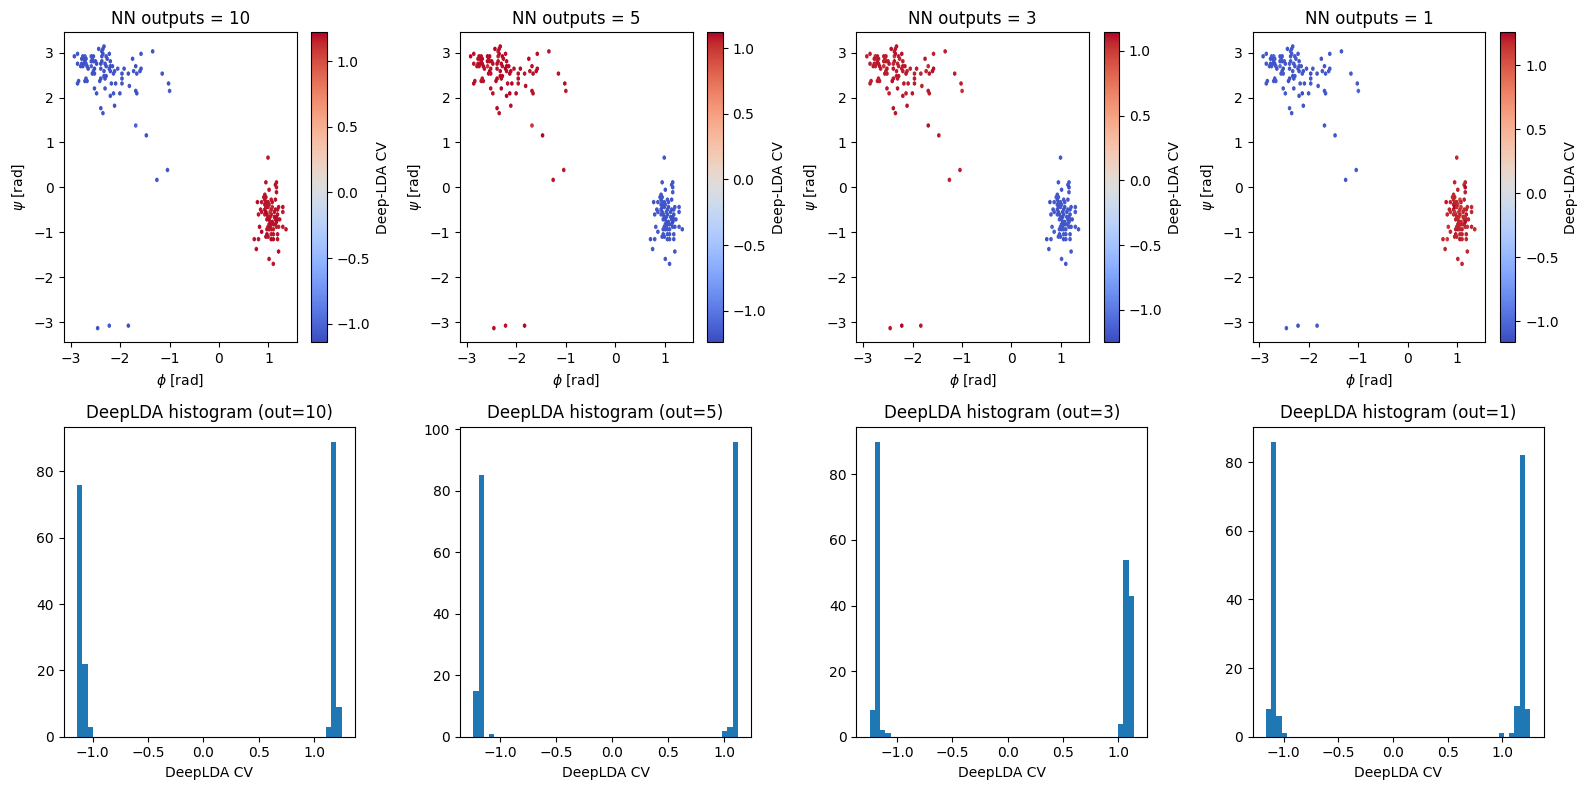

In [14]:
# ── Sweep over different NN output dimensionalities ───────────────────────
nn_out_values = [10, 5, 3, 1]

fig, axs = plt.subplots(2, len(nn_out_values), figsize=(16, 8), dpi=100)

for i, out in enumerate(nn_out_values):
    print(f"Training DeepLDA with NN output dim = {out} ...")

    layers_i = [n_features, 30, 30, out]
    model_i  = DeepLDA(layers_i, n_states=n_states,
                       options={'nn': {'activation': 'tanh'}})

    cb_i = MetricsCallback()
    es_i = EarlyStopping(
        monitor="valid_eigval_1_epoch", mode='max',
        min_delta=0.05, patience=20,
    )
    trainer_i = lightning.Trainer(
        callbacks=[cb_i, es_i], max_epochs=500,
        logger=None, enable_checkpointing=False,
        enable_progress_bar=False,
    )
    trainer_i.fit(model_i, datamodule)

    model_i.eval()
    with torch.no_grad():
        s_i = model_i(X)

    axs[0][i].set_title(f'NN outputs = {out}')
    plot_ramachandran(phi_vals, psi_vals, s_i.numpy().squeeze(), ax=axs[0][i])
    axs[1][i].set_title(f'DeepLDA histogram (out={out})')
    plot_cv_histogram(s_i, label='DeepLDA CV', bins=50, ax=axs[1][i])

plt.tight_layout()
plt.show()


#### Extra: features relevance

We can compute the relevance of the input features from the derivatives of the cv $s$ with respect to the descriptors $d_i$:
$$r_i = \sum_{j=1} ^{n} |\frac{\partial s^{(j)}}{\partial d_i ^{(j)}}|\ \sigma(d_i)$$
where the sum is over the configurations in the training set and $\sigma$ is the standard deviation of the descriptor.